import librarys

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

from sklearn.ensemble import GradientBoostingClassifier


load files

In [2]:
def load_files():
    meta   = pd.read_csv('metaData.csv')
    sample = pd.read_csv('sample_submission.csv')
    test   = pd.read_csv('test.csv')
    train  = pd.read_csv('train.csv')
    return meta, sample, train, test

meta, sample_submission, train, test = load_files()

print('Train shape:', train.shape)
print('Test  shape:', test.shape)

Train shape: (221, 37)
Test  shape: (95, 35)


In [3]:
meta.head()

,column,type,category,description,units,range
0,event_id,identifier,identifier,Anonymized fire event identifier (stable rando...,NaN,NaN
1,time_to_hit_hours,target,target,Time from t0+5h until fire comes within 5km of...,hours,"[0, 72]"
2,event,target,target,"Event indicator: 1 if fire hit within 72h, 0 i...",NaN,NaN
3,num_perimeters_0_5h,feature,temporal_coverage,Number of perimeters within first 5 hours,NaN,NaN
4,dt_first_last_0_5h,feature,temporal_coverage,Time span between first and last perimeter (ho...,NaN,NaN


In [4]:
sample_submission.head()

,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.5,0.5,0.5,0.5
1,13353600,0.5,0.5,0.5,0.5
2,13942327,0.5,0.5,0.5,0.5
3,16112781,0.5,0.5,0.5,0.5
4,17132808,0.5,0.5,0.5,0.5


In [5]:
train.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


In [6]:
train.columns

Index(['event_id', 'num_perimeters_0_5h', 'dt_first_last_0_5h',
       'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h',
       'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first',
       'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h',
       'radial_growth_m', 'radial_growth_rate_m_per_h',
       'centroid_displacement_m', 'centroid_speed_m_per_h',
       'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos',
       'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h',
       'dist_slope_ci_0_5h', 'closing_speed_m_per_h',
       'closing_speed_abs_m_per_h', 'projected_advance_m',
       'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_cos',
       'alignment_abs', 'cross_track_component', 'along_track_speed',
       'event_start_hour', 'event_start_dayofweek', 'event_start_month',
       'time_to_hit_hours', 'event'],
      dtype='object')

In [7]:
for i in train.columns:
    null_counts = (train[i] == 0).sum()
    percentage = (null_counts / len(train)) * 100
    print(f"Percentage of zeros: {i} :{percentage}%")

Percentage of zeros: event_id :0.0%
Percentage of zeros: num_perimeters_0_5h :0.0%
Percentage of zeros: dt_first_last_0_5h :72.39819004524887%
Percentage of zeros: low_temporal_resolution_0_5h :27.149321266968325%
Percentage of zeros: area_first_ha :0.0%
Percentage of zeros: area_growth_abs_0_5h :88.68778280542986%
Percentage of zeros: area_growth_rel_0_5h :88.68778280542986%
Percentage of zeros: area_growth_rate_ha_per_h :88.68778280542986%
Percentage of zeros: log1p_area_first :0.0%
Percentage of zeros: log1p_growth :89.14027149321268%
Percentage of zeros: log_area_ratio_0_5h :88.68778280542986%
Percentage of zeros: relative_growth_0_5h :88.68778280542986%
Percentage of zeros: radial_growth_m :88.68778280542986%
Percentage of zeros: radial_growth_rate_m_per_h :88.68778280542986%
Percentage of zeros: centroid_displacement_m :88.68778280542986%
Percentage of zeros: centroid_speed_m_per_h :88.68778280542986%
Percentage of zeros: spread_bearing_deg :88.68778280542986%
Percentage of zeros

In [8]:
test.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month
0,10662602,1,0.000000,1,2.452217,0.000000,0.00000,0.000000,1.239017,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0,3,7
1,13353600,1,0.000000,1,131.669588,0.000000,0.00000,0.000000,4.887862,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,22,0,8
2,13942327,1,0.000000,1,6.723104,0.000000,0.00000,0.000000,2.044216,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,2,6,7
3,16112781,1,0.000000,1,285.416736,0.000000,0.00000,0.000000,5.657448,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0,1,7
4,17132808,7,3.459331,0,61.098604,12.516633,0.20486,3.618224,4.128724,2.603921,...,13.54413,-22.687575,0.044572,0.15855,0.15855,-24.414806,3.920562,23,5,7


outliers clip

In [9]:
num_cols = [c for c in train.columns 
            if train[c].dtype in ['int64', 'float64']
            and c not in ['event_id', 'time_to_hit_hours', 'event']]

for col in num_cols:
    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr = q3 - q1

    if iqr == 0:
        continue

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (train[col] < lower_bound) | (train[col] > upper_bound)
    train.loc[outlier_mask, col] = train.loc[outlier_mask, col].clip(lower_bound, upper_bound)

    if col in test.columns:
        outlier_mask_test = (test[col] < lower_bound) | (test[col] > upper_bound)
        test.loc[outlier_mask_test, col] = test.loc[outlier_mask_test, col].clip(lower_bound, upper_bound)

C:\Users\abdullah\AppData\Local\Temp\ipykernel_17824\1744891739.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5
 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train.loc[outlier_mask, col] = train.loc[outlier_mask, col].clip(lower_bound, upper_bound)
C:\Users\abdullah\AppData\Local\Temp\ipykernel_17824\1744891739.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[3.5 3.5 3.5 3.5 3.5 3.5 3.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test.loc[outlier_mask_test, col] = test.loc[outlier_mask_test, col].clip(lower_bound, upper_bound)


data dispaly

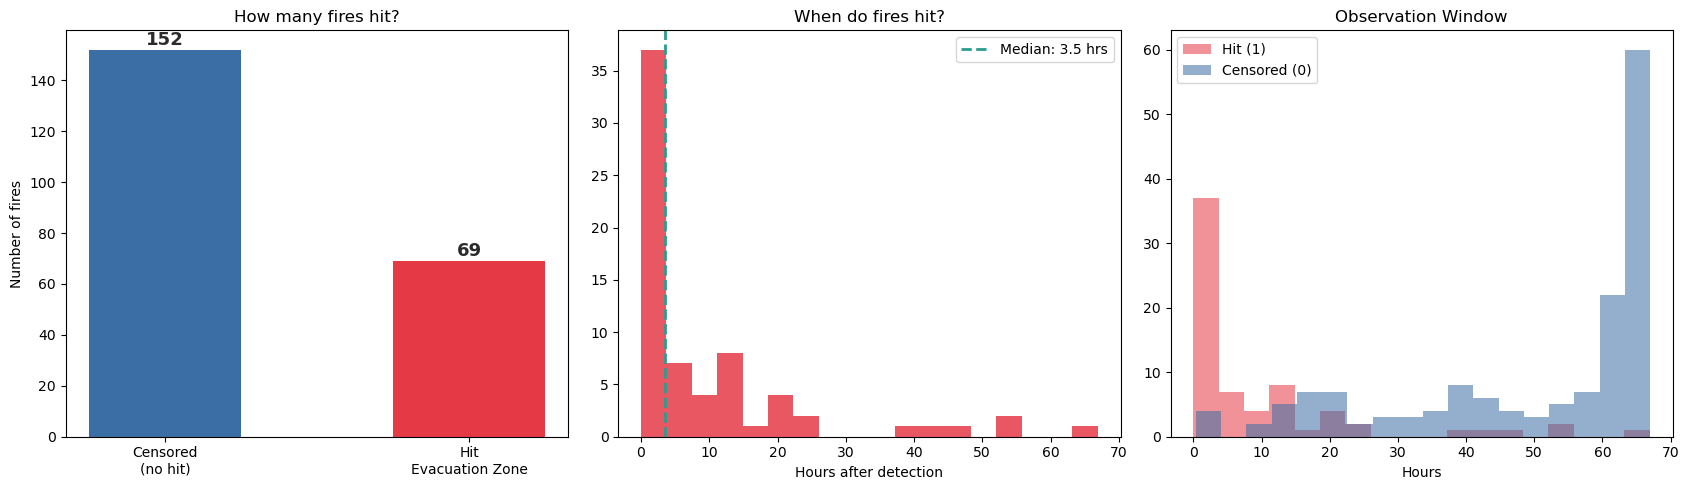

In [10]:
MISS_COLOR  = '#3A6EA5'
HIT_COLOR   = '#E63946'
TEXT_COLOR  = '#2B2B2B'
FIRE_COLOR  = '#2A9D8F'

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

counts = train['event'].value_counts().sort_index()
bars = axes[0].bar(
    ['Censored\n(no hit)', 'Hit\nEvacuation Zone'],
    counts.values,
    color=[MISS_COLOR, HIT_COLOR], edgecolor='none', width=0.5
)
for bar, cnt in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, cnt + 2,
                 str(cnt), ha='center', color=TEXT_COLOR,
                 fontweight='bold', fontsize=13)
axes[0].set_title('How many fires hit?')
axes[0].set_ylabel('Number of fires')

hits = train[train['event'] == 1]['time_to_hit_hours']
axes[1].hist(hits, bins=18, color=HIT_COLOR, alpha=0.85, edgecolor='none')
axes[1].axvline(hits.median(), color=FIRE_COLOR, ls='--', lw=2,
                label=f'Median: {hits.median():.1f} hrs')
axes[1].set_title('When do fires hit?')
axes[1].set_xlabel('Hours after detection')
axes[1].legend()

for label, color, mask in [
    ('Hit (1)', HIT_COLOR, train['event'] == 1),
    ('Censored (0)', MISS_COLOR, train['event'] == 0),
]:
    axes[2].hist(train.loc[mask, 'time_to_hit_hours'], bins=18, alpha=0.55,
                 color=color, label=label, edgecolor='none')
axes[2].set_title('Observation Window')
axes[2].set_xlabel('Hours')
axes[2].legend()

plt.tight_layout()
plt.show()

feature engineering

In [11]:
def feature_engineering(df):
    data = df.copy()
    
    speed = data['closing_speed_m_per_h'].clip(lower=0.01) if 'closing_speed_m_per_h' in data else 0.01
    dist = data['dist_min_ci_0_5h'].clip(lower=1) if 'dist_min_ci_0_5h' in data else 1

    if 'alignment_abs' in data:
        data['danger_vector'] = data['alignment_abs'] * speed
    if 'num_perimeters_0_5h' in data:
        data['tracking_urgency'] = data['num_perimeters_0_5h'] * speed
    if 'area_growth_rate_ha_per_h' in data and 'num_perimeters_0_5h' in data:
        data['fire_intensity'] = data['area_growth_rate_ha_per_h'] * data['num_perimeters_0_5h']

    data['speed_dist_ratio'] = speed / dist
    data['log_dist'] = np.log1p(dist)

    if 'event_start_hour' in data:
        data['hour_sin'] = np.sin(2 * np.pi * data['event_start_hour']/24.0)
        data['hour_cos'] = np.cos(2 * np.pi * data['event_start_hour']/24.0)

    # Clean infinities / NaN
    data = data.replace([np.inf, -np.inf], np.nan).fillna(0)
    return data


In [12]:
train_fe = feature_engineering(train)
test_fe  = feature_engineering(test)

spliting and modeling

In [13]:
X = train_fe.drop(columns=['event_id', 'time_to_hit_hours','event','event_start_hour'], errors='ignore')
X_test = test_fe.drop(columns=['event_id', 'time_to_hit_hours','event','event_start_hour'], errors='ignore')

In [14]:
submission = sample_submission.copy()

print("\nStarting Modeling...")
for h in [12, 24, 48, 72]:
    print(f'--- Training for {h} hours ---')

    y = ((train_fe['time_to_hit_hours'] <= h) & (train_fe['event'] == 1)).astype('int8')

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model = GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    preds_val = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds_val)
    print(f'Validation AUC for {h}h: {auc:.3f}')

    preds_test = model.predict_proba(X_test)[:, 1]
    submission[f'prob_{h}h'] = preds_test


Starting Modeling...
--- Training for 12 hours ---
Validation AUC for 12h: 0.985
--- Training for 24 hours ---
Validation AUC for 24h: 0.991
--- Training for 48 hours ---
Validation AUC for 48h: 0.998
--- Training for 72 hours ---
Validation AUC for 72h: 1.000


In [15]:
submission.to_csv('DSS-JUST.csv', index=False)
submission.head(20)

,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.002603,0.000280,0.000034,0.000036
1,13353600,0.667387,0.998538,0.999612,0.999914
2,13942327,0.001237,0.000152,0.000058,0.000036
3,16112781,0.888929,0.998538,0.999612,0.999914
4,17132808,0.000672,0.000062,0.000034,0.000036
5,17445696,0.001482,0.000269,0.000058,0.000036
6,17599982,0.003294,0.000502,0.000058,0.000036
7,18750374,0.153940,0.244575,0.992029,0.999914
8,21365245,0.001166,0.000155,0.000058,0.000036
9,23634840,0.055743,0.998919,0.999708,0.999914


In [16]:
submission.describe()

,event_id,prob_12h,prob_24h,prob_48h,prob_72h
count,9.500000e+01,95.000000,95.000000,95.000000,95.000000
mean,5.695393e+07,0.190746,0.281464,0.281681,0.294737
std,2.329721e+07,0.358896,0.444446,0.447510,0.458287
min,1.066260e+07,0.000287,0.000062,0.000034,0.000036
25%,4.027536e+07,0.001482,0.000269,0.000058,0.000036
50%,5.480111e+07,0.002345,0.000269,0.000058,0.000036
75%,7.536942e+07,0.072740,0.969220,0.994802,0.999914
max,9.964946e+07,0.998495,0.999707,0.999871,0.999914
